In [1]:
import time, math
import random as rd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

### Loading data

In [2]:
DATADIR = "data/"
START_END = None # will be define later

In [3]:
def load_from_data(data_path : str = "dj38.tsp") -> np.ndarray:
    """Charge les distances selon des données réelles
    Params
    --------
    data : nom d'un fichier de data rangé dans le dossier data"""

    data = None
    line_is_data = False
    with open(DATADIR + data_path, "r") as file:
        for line in file:
            # City
            if line.__contains__("locations in"):
                city = line.split(":")[-1].split(" ")[-1].replace("\n", "")

            # Declaration
            if line.__contains__("DIMENSION"):
                dim = int(line.replace(" ", "").split(":")[-1].replace("\n", ""))
                
                data = np.empty(shape = (0, 2), dtype = np.float32)

            # End of File, EOF
            if line.__contains__("EOF"):
                continue # To skip further instructions

            # Add coordinates
            if line_is_data:
                points = line.replace("\n", "").split(" ")
                assert len(points) == 3 # When adding new inputs, data may change
                points = np.array(points[1:], dtype = np.float32)
                data = np.vstack((data, points))

            # Tell when the coordinates section is reached from the file
            if line == "NODE_COORD_SECTION\n":
                line_is_data = True

    assert data.shape == (dim, 2)
    print(f"Data comes from city : {city}")

    # Calcul des distances entre toutes les villes
    diff = data[:, np.newaxis, :] - data[np.newaxis, :, :] # Differences between each cities
    distances = np.linalg.norm(diff, axis=2) # Distances between cities

    # Test for our matrix
    for i in range(len(distances)):
        for j in range(len(distances[0])):
            assert distances[i][j] == distances[j][i]

    return distances

In [4]:
# Matrice de distances entre les differentes villes
distances = [
    [0,1,2,3,4,5,6,1,7],
    [1,0,5,4,3,6,1,9,2],
    [2,5,0,1,6,1,9,3,7],
    [3,4,1,0,5,9,7,2,1],
    [4,3,6,5,0,9,1,2,1],
    [5,6,1,9,9,0,2,1,7],
    [6,1,9,7,1,2,0,4,5],
    [1,9,3,2,2,1,4,0,7],
    [7,2,7,1,1,7,5,7,0]
]

# Test for our matrix
for i in range(len(distances)):
    for j in range(len(distances[0])):
        assert distances[i][j] == distances[j][i]

### Implémentation des fonctions nécessaire a l'algorithme ABC

In [5]:
def generer_solution_aleatoire():
    """Cree un parcours aleatoirement"""

    original = list(range(1, len(distances) + 1))
    
    original.remove(START_END)
    rd.shuffle(original)

    return [int(START_END)] + original + [int(START_END)]

def generer_solutions_aleatoire(nb_solutions):
    """Cree nb parcours aleatoirement"""

    return [generer_solution_aleatoire() for _ in range(nb_solutions)]

In [6]:
def insert_segment(solution, segment):
    solution1 = solution.copy()
    # print(solution)
    number = solution1[segment[0]]

    for i in range(segment[0], segment[1]):
        solution1[i] = solution1[i+1]

    solution1[segment[1]] = number

    return solution1

def insert(solution):
    solution1 = solution.copy()
    position_ville = rd.randint(1, len(solution)-2)

    ville = solution1.pop(position_ville)
    nouvelle_position = rd.randint(1, len(solution)-2)

    solution1.insert(nouvelle_position, ville)
    return solution1

In [7]:
def calculer_distance(solution, distances):
    """Calcul le cout total d'une solution"""

    d = 0
    for i in range(len(solution) - 1):
        d += distances[solution[i] - 1][solution[i + 1] - 1]
    return d 

def genererSolutionVoisine(solution : list[int], flag = 0):
    """Effectue un swap aleatoire"""

    new_solution = solution.copy()

    # Technique swap
    if(flag == 0):
        index_i, index_j = rd.sample(range(1, len(new_solution)-1), 2)
        
        new_solution[index_i], new_solution[index_j] = new_solution[index_j], new_solution[index_i]
        return new_solution
    # Technique de segment
    if(flag == 1):
        segment = rd.sample(range(1, len(new_solution)-1), 2)
        segment.sort()
        t = insert_segment(new_solution,segment).copy()
        return t
    # Technique d'insertion
    if(flag == 2):
        t = insert(new_solution).copy()
        return t

In [ ]:
def Selection_roulette(fitness):
    """"""

    total = sum(fitness)
    prob = [f/total for f in fitness] 

    cumulative = []
    s=0
    for p in prob:
        s+=p
        cumulative.append(s)
    
    r = rd.random()

    for i,c in enumerate(cumulative):
        if r <= c :
            return i
    return -1

### Artificial Bee Colony (ABC) applied to Travelling Salesman Problem (TSP)

In [ ]:
def Colonies_abeilles_TSP(distance_matrix, max_it : int = 200, SN : int = 20, Limit: int = 20, flag : int = 0, early_stopping : int = math.inf) -> tuple[list[int], int]:
    solutions = generer_solutions_aleatoire(SN)
    trial = []
    fitness = []
    for i in range(SN):
        trial.append(0)
        fitness.append(calculer_distance(solutions[i], distance_matrix))

    Best = min(solutions, key=lambda p: calculer_distance(p, distance_matrix))
    early_stopping_list = [Best.copy()]

    for _ in range(max_it):
        # phase employees
        for i in range(SN):
            solution_v = genererSolutionVoisine(solutions[i], flag)
            if(calculer_distance(solution_v, distance_matrix) < calculer_distance(solutions[i], distance_matrix)):
                solutions[i] = solution_v
                fitness[i] = calculer_distance(solution_v, distance_matrix)
                trial[i] = 0
            else:
                trial[i]+=1
        
        #Phase observatrices
        for i in range(SN):
            index = Selection_roulette(fitness)
            solution_v = genererSolutionVoisine(solutions[index], flag=0)
            if calculer_distance(solution_v, distance_matrix) < calculer_distance(solutions[index], distance_matrix):
                solutions[index] = solution_v
                trial[index] = 0
            else:
                trial[index] += 1

        #Phase Elaireuses
        for i in range(SN):
            if trial[i] > Limit :
                solutions[i] = generer_solution_aleatoire()
                fitness[i] = calculer_distance(solutions[i], distance_matrix)

        Best = min(solutions, key=lambda p: calculer_distance(p, distance_matrix))

        # Early stopping
        if Best == early_stopping_list[-1]:
            # On ajoute pour pouvoir compter par la suite le nombre d'iteration similaires
            early_stopping_list.append(Best.copy())
        else:
            # On repart de 0 en prennant uniquemant la nouvelle solution optimale
            early_stopping_list = [Best.copy()]

        if len(early_stopping_list) > early_stopping:
            break
    
    return Best, calculer_distance(Best, distance_matrix)


In [10]:
START_END = 4
# START_END = rd.choice(range(1, len(distances) + 1)) # Id de la ville par la quelle on va commencer
print(f"Start and beginning is the city : {START_END}")

sol, cost = Colonies_abeilles_TSP(distances,200,20,20)
print(sol, cost)

Start and beginning is the city : 4
[4, 3, 6, 8, 1, 2, 7, 5, 9, 4] 9


### GridSearch

In [47]:
def GridSearchEval(iterations, SN, Limit, flags, distances=distances):
    results = []

    for t in iterations:
        for s in SN:
            for l in Limit:
                for f in flags:
                    result = {}
                    result["iterations"] = t
                    result["SN"] = s
                    result["Limit"] = l
                    result["flag"] = f
                    sol, fit = Colonies_abeilles_TSP(distances, t, s, l, f)
                    result["best_fitness"] = fit
                    result["best solution"] = sol
                    results.append(result)
    
    best_result = min(results, key=lambda x: x["best_fitness"])
    return best_result

In [14]:
print("Les meilleurs parametres sont :")
GridSearchEval([100,200,300],[10,20,30],[5,10,20], [0,1,2])

Les meilleurs parametres sont :


{'iterations': 100,
 'SN': 10,
 'Limit': 20,
 'flag': 0,
 'best_fitness': 9,
 'best solution': [4, 9, 5, 7, 2, 1, 8, 6, 3, 4]}

### Representation

In [16]:
G = nx.Graph()
for source, targets in enumerate(distances):
    for target, weight in enumerate(targets):
        if source != target:
            G.add_edge(source + 1, target + 1, weight=weight, layout_weight=1/weight)

print("Nombres de nœuds :", G.number_of_nodes())
print("Nombres d'arêtes :", G.number_of_edges())

Nombres de nœuds : 9
Nombres d'arêtes : 36


In [17]:
pos = nx.spring_layout(G, weight='layout_weight', seed=2048, k=1)
# pos = {
#     0 : (0, 2),
#     1 : (1, 3),
#     2 : (2.5, 0),
#     3 : (3, 1),
#     4 : (3, 3),
#     5 : (1.5, 0),
#     6 : (2, 4),
#     7 : (1, 1),
#     8 : (4, 2)
# }
print(pos)

{1: array([ 0.9539851 , -0.15173047]), 2: array([-0.20918035,  0.09239624]), 3: array([ 0.56067494, -0.56734321]), 4: array([-0.08770786, -1.        ]), 5: array([-0.94166273,  0.21641474]), 6: array([0.67021083, 0.84031283]), 7: array([-0.50454481,  0.93964424]), 8: array([0.47601712, 0.2743826 ]), 9: array([-0.91779224, -0.64407696])}


In [18]:
def plot_cities(G, pos, sol = None) -> None:
    for edge1, edge2 in G.edges:
        if sol:
            edge1_index, edge2_index = sol.index(edge1), sol.index(edge2)

            # Si les deux noeuds sont a une arrete de distance dans la solution, alors on les colorie
            if abs(edge1_index - edge2_index) == 1:
                G[edge1][edge2]["color"] = "#FF0000"
            elif edge1 == sol[-2] and edge2 == sol[-1]:
                G[edge1][edge2]["color"] = "#FF0000"
        else:
            G[edge1][edge2]["color"] = "#46464B"
    
    edge_color = [G[u][v]['color'] for u,v in G.edges]
    edge_labels = nx.get_edge_attributes(G, 'weight')
    
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
    nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, edge_color = edge_color)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    title = f"Graph representing our cities with solution in red" if sol else f"Graph representing our cities"
    plt.title(title)
    plt.axis('off')
    plt.show()

    if sol:
        print(f"La solution est {sol}")
        print(f"Le cout total de la solution vaut : {calculer_distance(sol, distances)}")

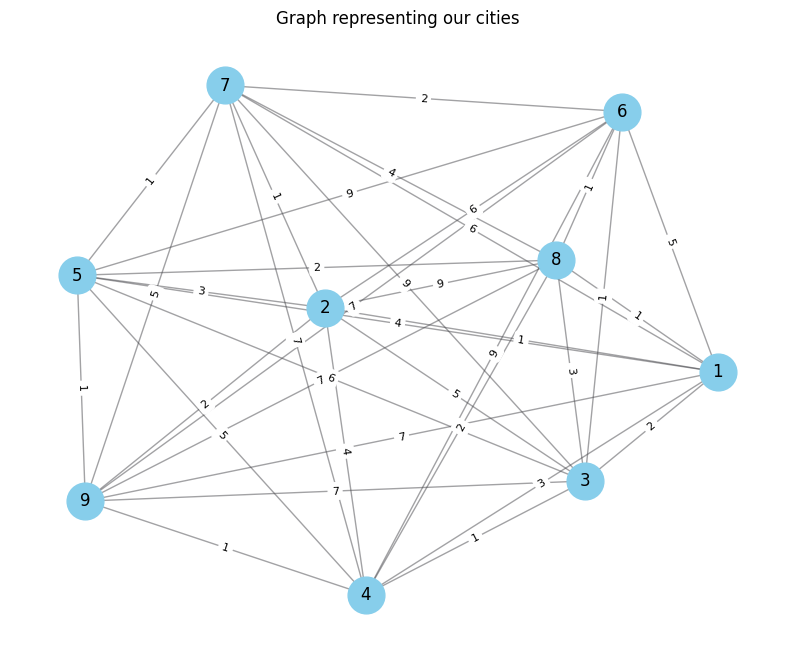

In [19]:
plot_cities(G, pos)

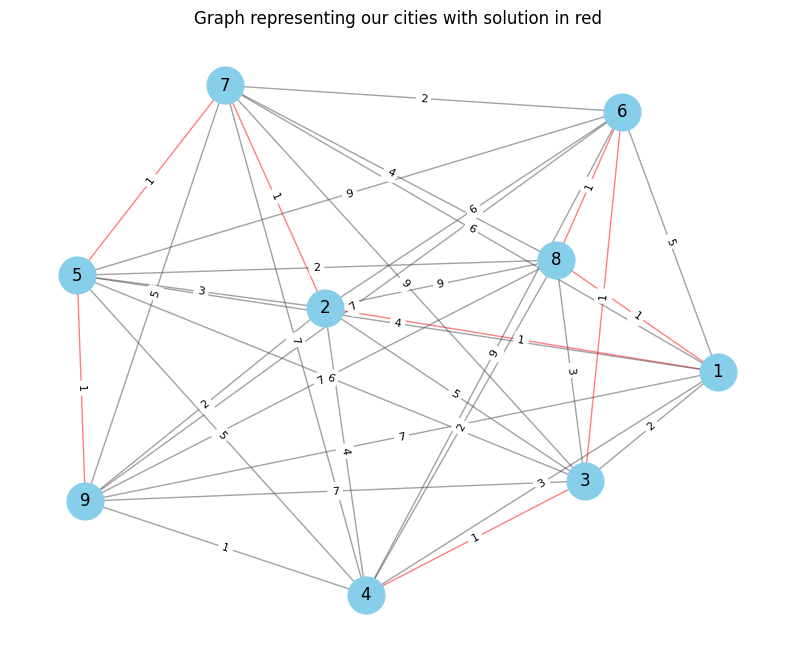

La solution est [4, 3, 6, 8, 1, 2, 7, 5, 9, 4]
Le cout total de la solution vaut : 9


In [20]:
plot_cities(G, pos, sol)

### Benchmarks

#### Methode Exact 

In [21]:
# %%
def permut(X, res):
    """Fais la permutation entre une position et un tuple"""

    new_X = X.copy()

    tmp = new_X[res[1]]
    new_X[res[1]] = new_X[res[0]]
    new_X[res[0]] = tmp
    
    return new_X


def add(X, V):
    """Realise l'operation d'addition sur toutes les permutations de V"""

    new_X = X.copy()

    for res in V:
        if not new_X:
            new_X = [res]
        elif type(new_X[0]) == list:
            new_X.append(res)
        else:
            new_X = permut(new_X, res)

    return new_X

# %%
def sub(P, X):
    """Donne les permutations a effectuer pour arriver a X en partant de P"""
    
    res = []

    X_changed = X.copy()
    while not P.__eq__(X_changed): # Tant qu'on a pas retrouve le chemin initial
        resi = [-1, -1]
        vi = -1
        for i, (p, xc) in enumerate(zip(P, X_changed)):
            if p != xc:
                resi[0] = i
                vi = p

                break

        if vi == -1:
            # Il n'y a pas de difference, on a donc fini

            continue # Reviens a la condition while qui devrait s'arreter, est plus coherent qu'un break

        # On prend la position dans la liste de x qui a la valeur differente de p
        for i, xc in enumerate(X_changed):
            if vi == xc:
                resi[1] = i

        X_changed = permut(X_changed, resi)
        res.append(resi)

    # On inverse pour pouvoir avoir les operations dans le bon ordre
    return list(reversed(res))


x1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1]
x2 = [1, 4, 3, 2, 5, 6, 7, 8, 9, 1]

assert add(x1, sub(x1, x2)).__eq__(x2) # Test

# %%
def mul(k, V):
    if 0 < k < 1:
        k = max(int(k * len(V)), 1) # Pour obtenir au moins un V non vide
        V = V[:k]
    else:
        if k == int(k): # Si c'est un entier
            V = V + V # La concatenation
        else:
            if k > 1:
                k = k - int(k) # On retire la partie entiere
                V = mul(k, V)
            else:
                if k < 1:
                    k = -k
                    V = mul(k, V)
    
    return V

def PSO_TSP(distances, nb_particles : int = 30, max_iter : int = 200):
    X = generer_solutions_aleatoire(nb_particles)
    P = X.copy()
    V = [[] for _ in range(len(X))]

    ro = np.random.uniform()

    i = 0
    while i < max_iter:
        b1 = np.random.uniform()
        b2 = np.random.uniform()

        P_G = min(P, key = lambda x : calculer_distance(x, distances))

        # We update each Vi and Xi to Vi+1 and Xi+1
        for j, (x, p, v) in enumerate(zip(X, P, V)):
            a1 = mul(ro, v)
            a2 = sub(p, x)
            a3 = sub(P_G, x)
            a4 = mul(b1, a2)
            a5 = mul(b2, a3)
            a6 = add(a1, a4)

            V[j] = add(a6, a5)
            X[j] = add(x, v)

        # We update our solution by keeping best ones
        for j, (x, p) in enumerate(zip(X, P)):
            if calculer_distance(x, distances) < calculer_distance(p, distances):
                P[j] = x

        i += 1
        
    P_G0 = min(P, key = lambda x : calculer_distance(x, distances))

    return P_G0, calculer_distance(P_G0, distances)

In [22]:
def neighboor_insert(X : list[int]):
    """Option 1, choisi une valeur au hasard et l'insert"""

    new_X = X.copy()
    new_X = new_X[1:-1]

    random_elem = rd.choice(new_X)
    new_X.remove(random_elem)
    new_X.insert(rd.choice(range(len(new_X) + 1)), random_elem)

    return [int(START_END)] + new_X + [int(START_END)]

def simulated_annealing_TSP(distances : list, neighboor = neighboor_insert, T0 = 1000, TB = 1e-8, learning_rate = 0.99, NTF = 5, max_iter = 200):
    T = T0
    x0 = generer_solution_aleatoire()
    x = [(x0, calculer_distance(x0, distances))]
    x_best, fx_best = x[0]
    n = 4

    while T >= TB:
        
        i = 0
        while i < NTF:
            z = neighboor(x[-1][0])
            hz = calculer_distance(z, distances)
            hxn = calculer_distance(x[-1][0], distances)

            if hz < hxn:
                x.append((z, hz))

                if hxn < fx_best:
                    x_best, fx_best = x[-1]
            else:
                p = np.exp(-(hz - hxn) / T)
                alea = np.random.rand()
                if alea < p:
                    x.append((z, hz))
                else:
                    x.append((x[-1][0], hxn))

            i += 1
        
        n *= learning_rate
        T *= learning_rate

    return x_best, fx_best

In [23]:
def ant_colony_optimization(
    dist_mat, 
    n_ants=10, 
    n_iterations=50, 
    alpha=1.0,   # Pheromone importance
    beta=2.0,    # Distance importance (heuristic)
    rho=0.1,     # Evaporation rate
    Q=1.0        # Pheromone deposit factor
):
    """
    Generic ACO for TSP.
    dist_mat: Square matrix of costs
    """
    n = dist_mat.shape[0]
    
    # Initialize Pheromones (small non-zero value)
    pheromones = np.ones((n, n))
    
    # Heuristic matrix (1/distance). Avoid division by zero on diagonal.
    with np.errstate(divide='ignore'):
        eta = 1.0 / dist_mat
    eta[np.isinf(eta)] = 0
    
    best_path = None
    best_cost = float('inf')

    for iteration in range(n_iterations):
        all_paths = []
        all_costs = []
        
        # 1. GENERATE ANT PATHS
        for ant in range(n_ants):
            path = [START_END]
            visited = {START_END}
            
            while len(visited) < n:
                i = path[-1]
                
                # Calculate transition probabilities
                # P = (pheromone^alpha) * (heuristic^beta)
                probabilities = (pheromones[i] ** alpha) * (eta[i] ** beta)
                
                # Mask visited nodes
                mask = np.ones(n, dtype=bool)
                mask[list(visited)] = False
                probabilities[~mask] = 0
                
                # Normalize
                prob_sum = probabilities.sum()
                if prob_sum == 0: # Fallback if path is blocked
                    probabilities[mask] = 1 / mask.sum()
                else:
                    probabilities /= prob_sum
                
                # Choose next node
                next_node = np.random.choice(range(n), p=probabilities)
                path.append(next_node)
                visited.add(next_node)
            
            # Close the loop (return to start)
            path.append(START_END)
            
            # Calculate cost
            cost = sum(dist_mat[path[k], path[k+1]] for k in range(len(path)-1))
            
            all_paths.append(path)
            all_costs.append(cost)
            
            if cost < best_cost:
                best_cost = cost
                best_path = path

        # 2. EVAPORATION
        pheromones *= (1 - rho)
        
        # 3. DEPOSIT PHEROMONES
        for path, cost in zip(all_paths, all_costs):
            deposit = Q / cost
            for k in range(len(path) - 1):
                pheromones[path[k], path[k+1]] += deposit
                pheromones[path[k+1], path[k]] += deposit # Symmetric

    # Convert indices back to original labels
    return best_path, best_cost

In [24]:
def replace_doubles_by_missing(original, new):
    """Remplace les valeurs en doublon dans la liste pas les valeurs manquantes presentes dans l'orignale"""

    values_OG = set(original)
    values_missing = list(values_OG - set(new)) # Sert a identifier les villes manquantes (du aux doublons)

    doubles = []
    replaced_list = []

    for x in new:
        if x == int(START_END): # Si c'est notre point de depart ou d'arrive, on ne tient pas compte de sa frequence
            replaced_list.append(x)
        elif x not in doubles: # Si c'est une valeur qui est pour le moment unique, on l'ajoute
            replaced_list.append(x)
            doubles.append(x)
        else: # Si c'est un doublons, alors on la remplace par une des valeurs manquantes
            random_missing = rd.choice(values_missing)

            replaced_list.append(random_missing)
            values_missing.remove(random_missing)

    return replaced_list # On retourne alors la nouvelle liste composee de valeurs unique (hormis POINT) et de taille identique
    

def croisement(x1 : list[int], x2 : list[int]):
    """Realise l'operation de croisement sur deux villes"""

    assert len(x1) >= 4 and len(x2) >= 4

    # On recupere l'indice du milieu sur lequel on va split
    mid = rd.choice(range(1, 8 + 1)) # len(x1) // 2
    
    # On realise l'operation de croisement
    xx1, xx2 = x1[:mid] + x2[mid:], x2[:mid] + x1[mid:]

    # On realise le pre-traitement en supprimant les doublons et en les renplacants    
    xx1 = replace_doubles_by_missing(x1, xx1)
    xx2 = replace_doubles_by_missing(x2, xx2)

    return xx1, xx2

def mutation(pop : list[list[int]]):
    """Realise la mutation en avancant ligne par ligne"""

    # Cree la nouvelle liste apres croisement
    res = []
    for i in range(0, len(pop) - 1, 2):
        res += list(croisement(pop[i], pop[i + 1])).copy()
    if len(res) < len(pop):
        res += [pop[-1]].copy()

    return res

def algo_genetique(distances, nb_solutions : int = 20, max_iter = 50):
    population = generer_solutions_aleatoire(nb_solutions)

    for i in range(max_iter):
        new_list = mutation(population) # On fait la mutation

        # On cree une liste total avec tous les couts
        cost_list = []
        for x in population + new_list:
            cost_list.append((x, calculer_distance(x, distances)))

        # On recupere les meilleurs parmi la population et la mutation
        best = []
        while len(best) < max(len(population) - 0, 1): # max(len(population) - 1, 1) pour augmenter rapidement la vitesse de convergence
            mini = math.inf
            mini_index = math.inf
            mini_cost = math.inf
            for i, (x, cx) in enumerate(cost_list):
                if cx < mini_cost:
                    mini = x
                    mini_index = i
                    mini_cost = cx

            best.append(mini)
            cost_list.pop(mini_index)

        population = best # On recupere les meilleurs valeurs pour re-iterer dessus
        rd.shuffle(population) # On melange pour converger plus vite avec le croisement

    couts = [calculer_distance(x, distances) for x in population]
    indice_minimum = couts.index(min(couts))
    
    return population[indice_minimum], couts[indice_minimum]

In [31]:
def benchmark(mean : int = 50):
    distances = ["wi29.tsp", "dj38.tsp", "qa194.tsp", "uy734.tsp"]
    distances = list(map(load_from_data, distances))

    T = {"ABC" : [], "PSO" : [], "Simulated Annealing" : [], "Fourmis" : [], "Algo génétique" : []}
    costs = np.array([0 for _ in range(len(T))])
    for distance in distances:
        t = {x : [] for x in T.keys()}
        for _ in range(mean):
            cost_x = []

            start = time.time()
            sol, cost = Colonies_abeilles_TSP(distance, max_it = 200)
            t["ABC"].append(time.time() - start)
            cost_x.append(cost)

            start = time.time()
            sol, cost = PSO_TSP(distance, max_iter = 200)
            t["PSO"].append(time.time() - start)
            cost_x.append(cost)

            start = time.time()
            sol, cost = simulated_annealing_TSP(distance, max_iter = 200)
            t["Simulated Annealing"].append(time.time() - start)
            cost_x.append(cost)

            start = time.time()
            sol, cost = ant_colony_optimization(distance, n_iterations = 200)
            t["Fourmis"].append(time.time() - start)
            cost_x.append(cost)

            start = time.time()
            sol, cost = algo_genetique(distance, max_iter = 200)
            t["Algo génétique"].append(time.time() - start)
            cost_x.append(cost)

            # Computing the best algo
            cost_x = np.array(cost_x)
            costs += np.where(cost_x == np.min(cost_x), 1, 0)

        for x in T.keys():
            T[x].append(np.mean(t[x]))

    print(f"L'algo renvoyant le plus souvent les meilleures solutions (en terme de coût) est : {list(T.keys())[np.argmax(costs)]}")

    D = list(map(len, distances))

    return D, T

def plot_benchmark(D,T):

    plt.figure(figsize = (12, 8))
    plt.title("Temps d'exécution en fonction du nombre de villes")
    plt.yscale("log")
    plt.xlabel("Nombre de villes")
    plt.ylabel("Temps d'exécution (s)")

    # Plot each algo
    for t in T.keys():
        plt.plot(D, T[t], label = t)
        plt.scatter(D, T[t], marker = "*", c = "r")

    # Plot each data
    T_values = list(T.values())
    for i, d in enumerate(D):
        T_value = [t[i] for t in T_values]
        ymin, ymax = min(T_value), max(T_value)
        plt.vlines(d, ymin = ymin, ymax = ymax, colors = 'r', linestyles = "dashed")
        plt.text(d, ymax, s = d)

    plt.legend(loc = "upper left")
    plt.show()

Data comes from city : Sahara
Data comes from city : Djibouti
Data comes from city : Qatar
Data comes from city : Uruguay
L'algo renvoyant le plus souvent les meilleures solutions (en terme de coût) est : Simulated Annealing


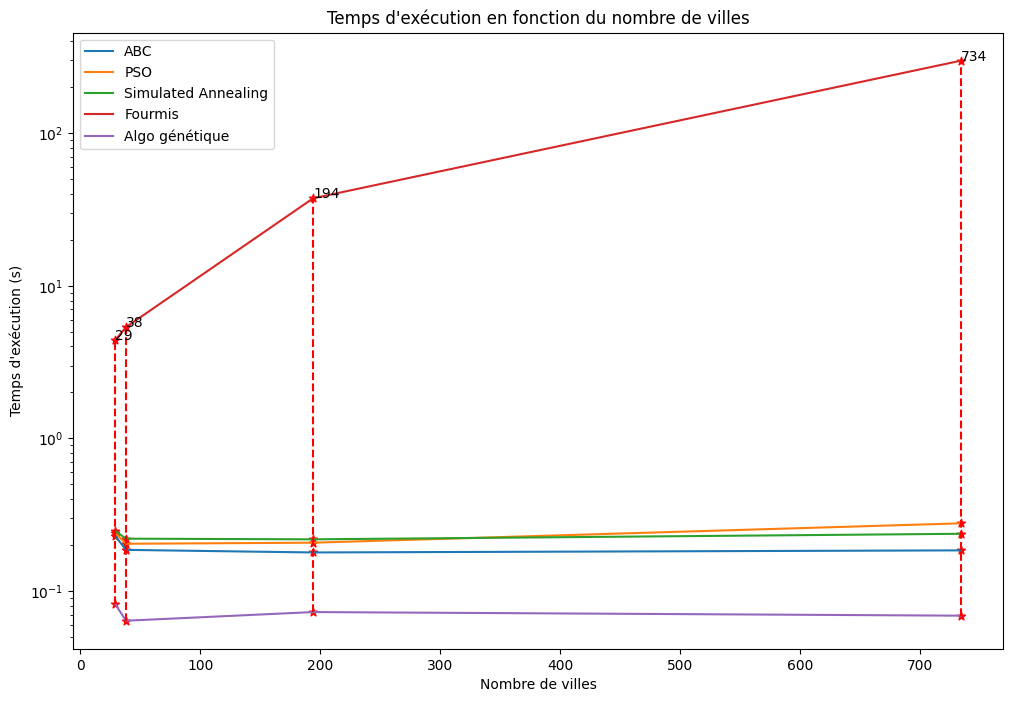

In [32]:
D, T = benchmark(5)
plot_benchmark(D, T)

## Benchmark ACB VS DFS

### Methode Exact : DFS avec timer

In [62]:
import numpy as np
import time

def tsp_dfs(distance_matrix: np.ndarray, time_limit: float = 10.0):
    """
    Résout le TSP avec DFS et un temps limite.
    
    Params
    -------
    distance_matrix : np.ndarray
        Matrice de distances symétrique générée par load_from_data
    time_limit : float
        Temps maximum d'exécution en secondes

    Returns
    -------
    best_path : list
        Ordre des villes pour le meilleur chemin trouvé
    best_cost : float
        Coût total du meilleur chemin trouvé
    """

    n = distance_matrix.shape[0]
    best_cost = float('inf')
    best_path = []
    start_time = time.time()

    def dfs(current_path, visited, current_cost):
        nonlocal best_cost, best_path

        # Stop si on dépasse le temps limite
        if time.time() - start_time > time_limit:
            return

        # Si toutes les villes sont visitées, compléter le cycle
        if len(current_path) == n:
            total_cost = current_cost + distance_matrix[current_path[-1], current_path[0]]
            if total_cost < best_cost:
                best_cost = total_cost
                best_path = current_path.copy()
            return

        # Explorer les voisins non visités
        for next_city in range(n):
            if not visited[next_city]:
                visited[next_city] = True
                dfs(current_path + [next_city], visited, current_cost + distance_matrix[current_path[-1], next_city])
                visited[next_city] = False  # backtrack

    # Initialiser DFS depuis la ville 0
    visited = [False] * n
    visited[0] = True
    dfs([0], visited, 0.0)

    return best_cost

### ACB Avec timer

In [ ]:
def Colonies_abeilles_TSP_exec(distance_matrix, SN : int = 20, Limit: int = 20, flag : int = 0, time_limit = 10) -> tuple[list[int], int]:
    solutions = generer_solutions_aleatoire(SN)
    trial = []
    fitness = []
    for i in range(SN):
        trial.append(0)
        fitness.append(calculer_distance(solutions[i], distance_matrix))

    Best = min(solutions, key=lambda p: calculer_distance(p, distance_matrix))
    start_time = time.time()
    while time.time() - start_time < time_limit:
        for i in range(SN):
            solution_v = genererSolutionVoisine(solutions[i], flag)
            if(calculer_distance(solution_v, distance_matrix) < calculer_distance(solutions[i], distance_matrix)):
                solutions[i] = solution_v
                fitness[i] = calculer_distance(solution_v, distance_matrix)
                trial[i] = 0
            else:
                trial[i]+=1
        
        #Phase observatrices
        for i in range(SN):
            index = Selection_roulette(fitness)
            solution_v = genererSolutionVoisine(solutions[index], flag=0)
            if calculer_distance(solution_v, distance_matrix) < calculer_distance(solutions[index], distance_matrix):
                solutions[index] = solution_v
                trial[index] = 0
            else:
                trial[index] += 1

        #Phase Elaireuses
        for i in range(SN):
            if trial[i] > Limit :
                solutions[i] = generer_solution_aleatoire()
                fitness[i] = calculer_distance(solutions[i], distance_matrix)

        Best = min(solutions, key=lambda p: calculer_distance(p, distance_matrix))
    
    return Best, calculer_distance(Best, distance_matrix)


In [126]:
def benchmark_dfs_acb(instances = ["wi29.tsp", "dj38.tsp"], executions_time = [5,10,20,30]):
    dfs_results = {
        "wi29.tsp" : [],
        "dj38.tsp" : [],
    }
    acb_results = {
        "wi29.tsp" : [],
        "dj38.tsp" : [],
    }

    for instance in instances:
        distances = load_from_data(instance)
        for exec in executions_time:
            dfs_results[instance].append(tsp_dfs(distances, exec))
            acb_results[instance].append(Colonies_abeilles_TSP_exec(distance_matrix=distances, time_limit=exec, SN=50, Limit=20, flag=1))
    
    return dfs_results, acb_results

In [149]:
import matplotlib.pyplot as plt
import numpy as np

def plot_benchmark_dfs_acb(dfs_results, acb_results, executions_time=[5,10,20,30], optimum=[27603, 6656], instances = ["wi29.tsp", "dj38.tsp"]):

    instance = 'wi29.tsp'
    for i in range(len(instances)):
        # Récupération des résultats
        results_dfs = dfs_results[instances[i]]
        results_acb = [t[1] for t in acb_results[instances[i]]]

        # Conversion en numpy pour faciliter le décalage
        x = np.arange(len(executions_time))

        # largeur des barres
        width = 0.35

        plt.figure(figsize=(10,6))

        # Barres DFS
        plt.bar(x - width/2, results_dfs,
                width=width,
                label='DFS',
                edgecolor='black')

        # Barres ABC
        plt.bar(x + width/2, results_acb,
                width=width,
                label='ABC',
                edgecolor='black')

        # Ligne optimum
        plt.axhline(y=optimum[i],
                    linestyle='--',
                    linewidth=2,
                    label='Optimum', color="red")

        # Labels axe X
        plt.xticks(x, executions_time)

        # Titres
        plt.title(f"Comparaison des performances DFS vs ABC pour l'instance {instances[i]}", fontsize=14, fontweight='bold')
        plt.xlabel("Temps d'exécution (secondes)", fontsize=12)
        plt.ylabel("Coût obtenu", fontsize=12)

        # Grille
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Légende
        plt.legend()

        # Améliorer les marges
        plt.tight_layout()

        plt.show()

In [127]:
dfs_results, acb_results = benchmark_dfs_acb()

Data comes from city : Sahara
Data comes from city : Djibouti


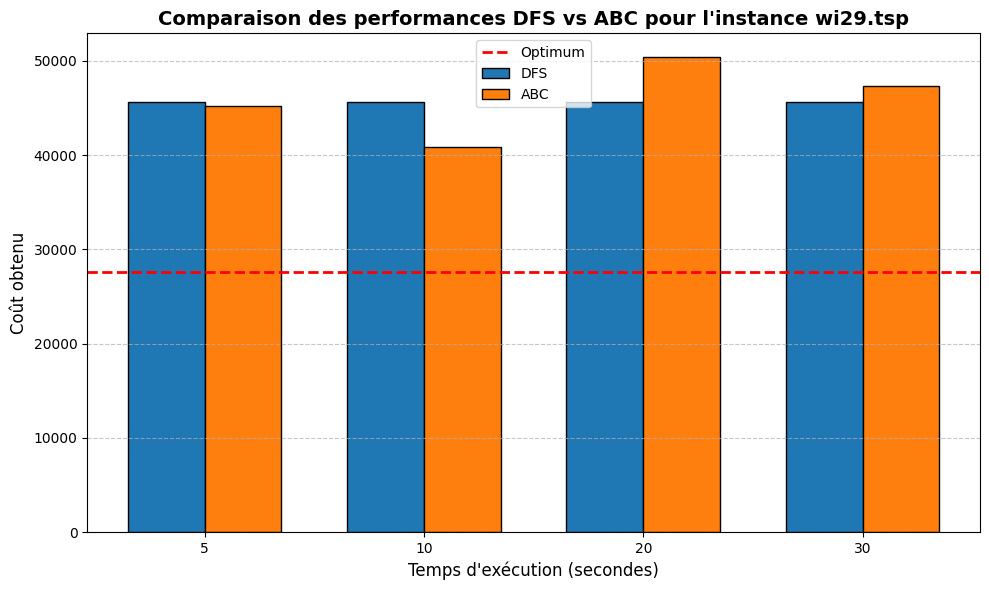

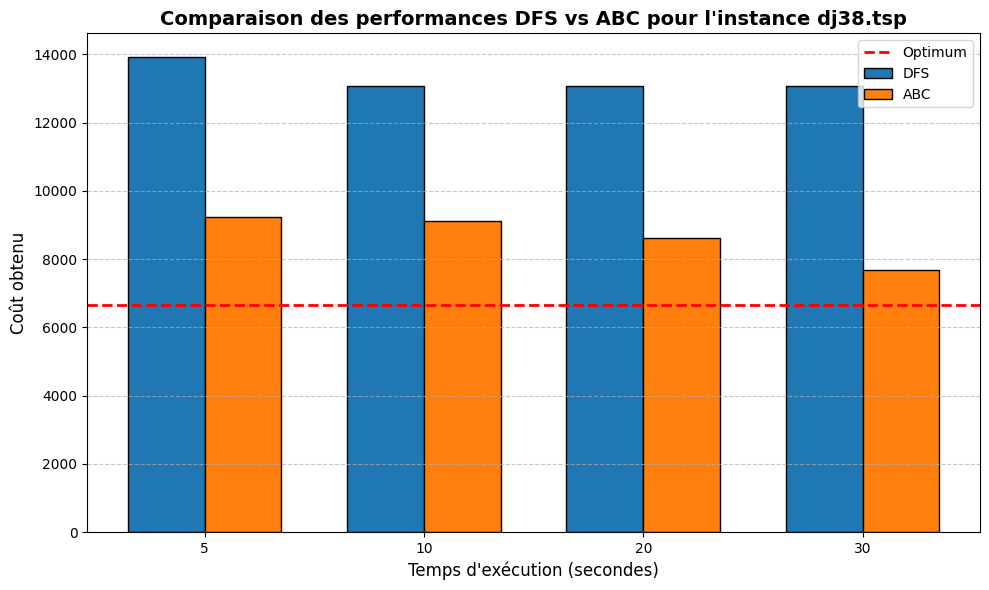

In [150]:
plot_benchmark_dfs_acb(dfs_results, acb_results)